# West Coast Housing Analysis: Part 2: Exploratory Data Analysis

**Inputs:** `data/processed/zhvi_long.parquet` · `data/processed/city_snapshot.parquet`  
**Geography:** California · Washington · Oregon · Nevada -- 1,406 cities  
**Time span:** June 2015 – June 2025 (121 months)

---

## Objectives

1. **State-level trends**: how do CA, WA, OR, and NV diverge over 10 years?
2. **Year-over-year dynamics**: when did markets accelerate, peak, and correct?
3. **ZHVI distribution**: what does the spread of city values look like within each state?
4. **Metro-level appreciation**: which markets compounded the most?
5. **COVID-era shock analysis**: pandemic boom and rate-hike correction in the data
6. **Appreciation vs. volatility**: is there a risk-return tradeoff in West Coast housing?
7. **Seasonal patterns**: does housing have a predictable calendar rhythm?
8. **Feature correlation**: which engineered variables will matter most in Part 3?

## 1) Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (13, 5)})

# State color palette — consistent across all plots

COLORS = {'CA': '#4878CF', 'WA': '#6ACC65', 'OR': '#D65F5F', 'NV': '#B47CC7'}

pd.set_option('display.float_format', '${:,.0f}'.format)

print('Ready.')

Ready.


## 2) Load Processed Data

In [5]:
df = pd.read_parquet('zhvi_long.parquet')
cs = pd.read_parquet('city_snapshot.parquet')

print(f'Time series (long):  {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'City snapshot:       {cs.shape[0]:,} rows × {cs.shape[1]} columns')
print(f'Date range:          {df["date"].min().date()} → {df["date"].max().date()}')
print(f'States:              {sorted(df["State"].unique())}')
print(f'Null ZHVI remaining: {df["zhvi"].isnull().sum()}')

Time series (long):  170,126 rows × 18 columns
City snapshot:       1,406 rows × 18 columns
Date range:          2015-06-30 → 2025-06-30
States:              ['CA', 'NV', 'OR', 'WA']
Null ZHVI remaining: 0


## 3) State-Level ZHVI Trends (2015–2025)

The core story of the dataset: how did median home values evolve across four West Coast states over a decade that included a prolonged low-rate expansion, a pandemic-driven demand shock, and an aggressive rate-hike correction.

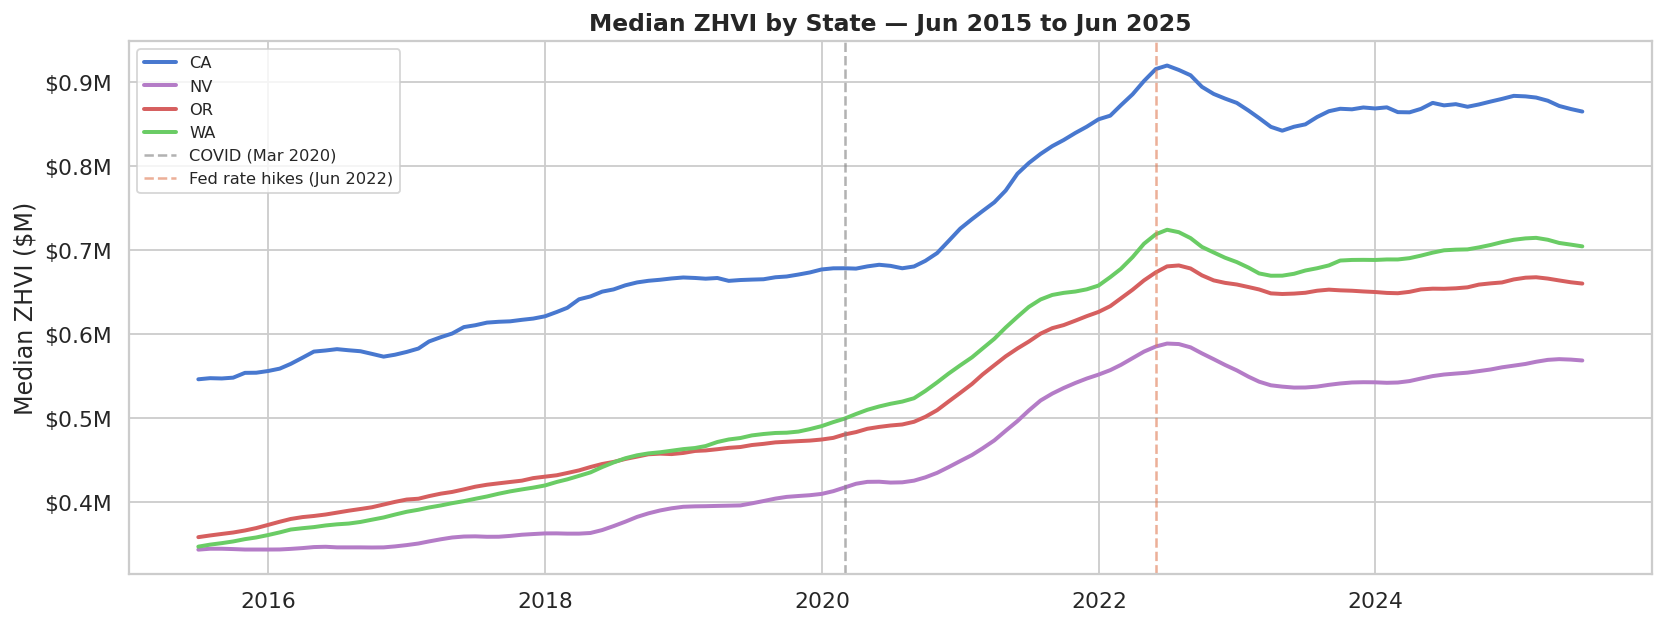

State Median ZHVI — Jun 2015 vs Jun 2025:
  CA: $546K → $865K  (+58.3%)
  WA: $347K → $705K  (+102.9%)
  OR: $359K → $660K  (+84.1%)
  NV: $344K → $569K  (+65.5%)


In [7]:
state_monthly = df.groupby(['State', 'date'])['zhvi'].median().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
for state, grp in state_monthly.groupby('State'):
    ax.plot(grp['date'], grp['zhvi'] / 1e6, label=state,
            color=COLORS[state], linewidth=2.2)

ax.axvline(pd.Timestamp('2020-03-01'), color='gray',
           linestyle='--', alpha=0.6, linewidth=1.4, label='COVID (Mar 2020)')
ax.axvline(pd.Timestamp('2022-06-01'), color='#e07b54',
           linestyle='--', alpha=0.6, linewidth=1.4, label='Fed rate hikes (Jun 2022)')

ax.set_ylabel('Median ZHVI ($M)')
ax.set_title('Median ZHVI by State — Jun 2015 to Jun 2025', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('state_median_zhvi_over_time.png', bbox_inches='tight')
plt.show()

# State snapshot summary

latest_date = df['date'].max()
earliest_date = df['date'].min()
print('State Median ZHVI — Jun 2015 vs Jun 2025:')
for state in ['CA', 'WA', 'OR', 'NV']:
    v15 = state_monthly[(state_monthly['State']==state) &
                         (state_monthly['date']==earliest_date)]['zhvi'].values[0]
    v25 = state_monthly[(state_monthly['State']==state) &
                         (state_monthly['date']==latest_date)]['zhvi'].values[0]
    chg = (v25 - v15) / v15 * 100
    print(f'  {state}: ${v15/1e3:,.0f}K → ${v25/1e3:,.0f}K  (+{chg:.1f}%)')

**Observations:**
- All four states show broadly parallel trajectories, reflecting national macro forces (rates, demand), but with clear divergence in magnitude.
- California maintains the highest median ZHVI throughout, widening its gap over the decade.
- Washington shows the sharpest acceleration through 2021 relative to its 2015 baseline.
- Both COVID reference lines are visible in the data: a brief late-2020 slowdown followed by the strongest appreciation surge in the dataset, then a meaningful correction beginning mid-2022 as the Fed began its fastest rate-hike cycle in 40 years.

## 4) Year-over-Year Growth by State

MoM percentage changes smooth into noise quickly. YoY is the right lens for understanding housing market regimes, it removes seasonal effects and reveals true cyclical acceleration and deceleration.

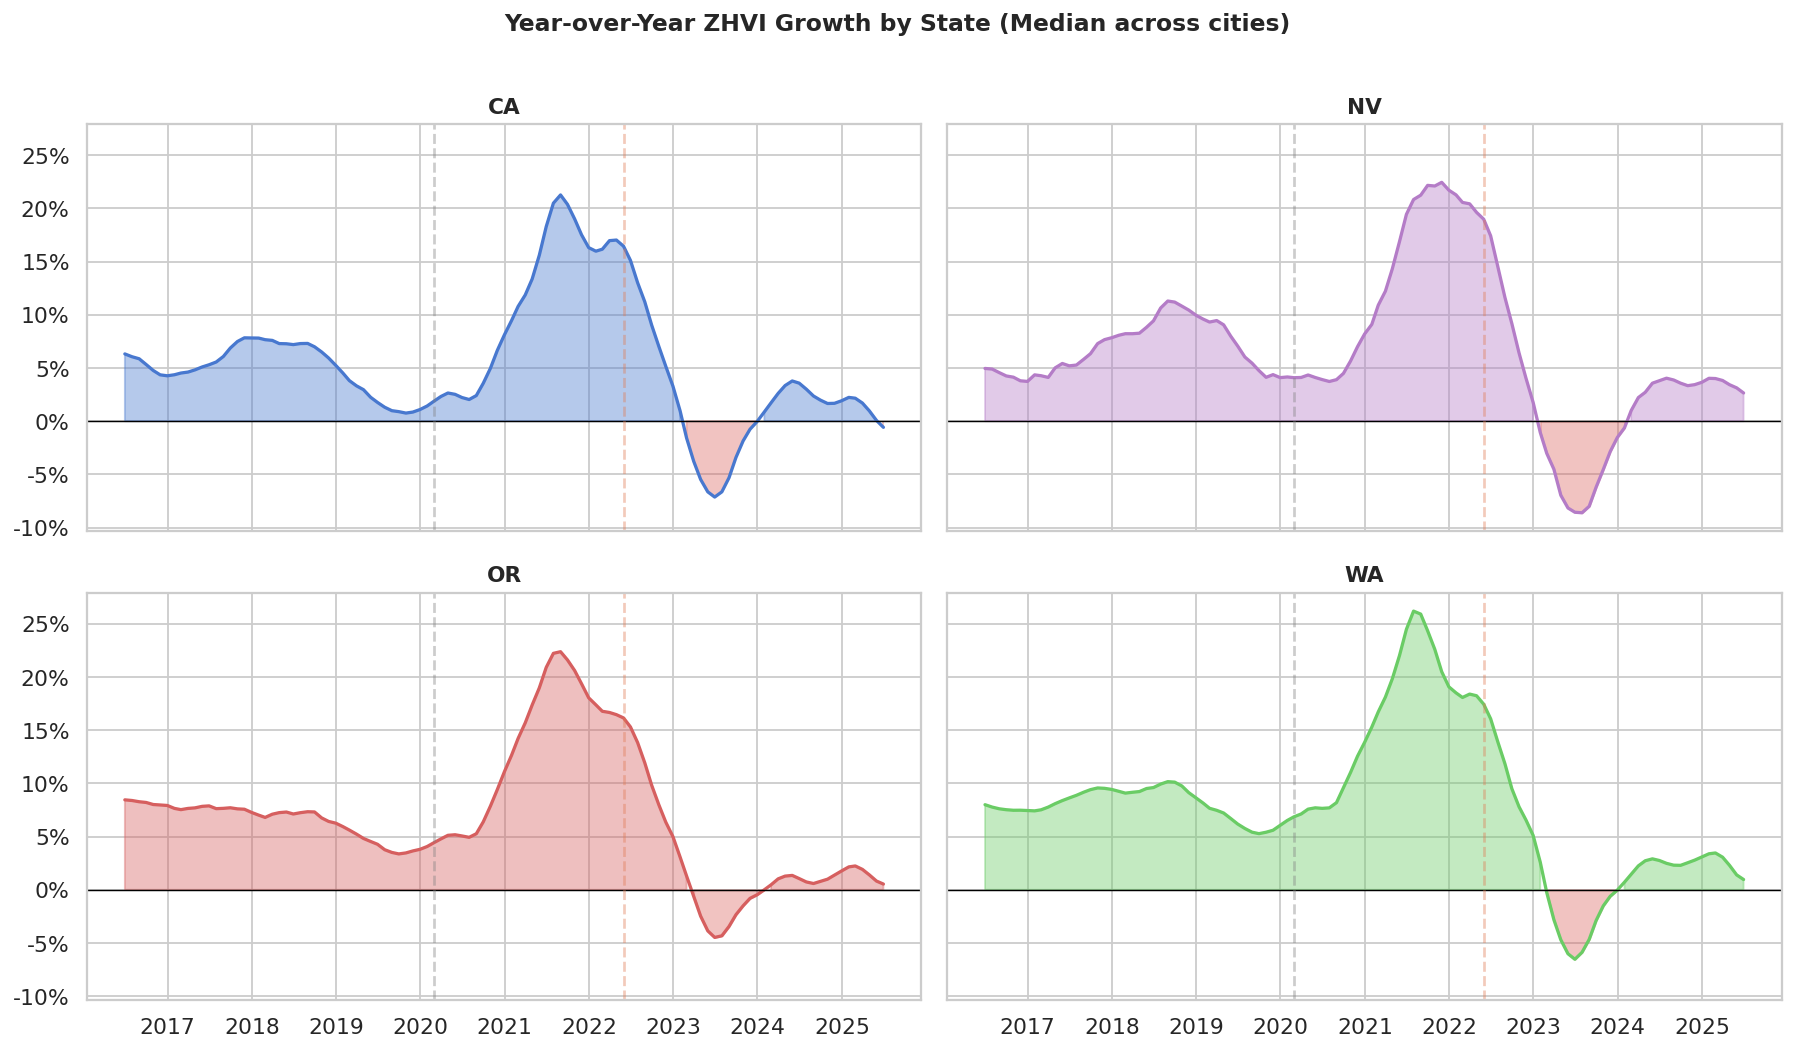

Peak and trough YoY by state (2016–2025):
  CA  Peak: 21.3% (Aug 2021)  | Trough: -7.1% (Jun 2023)
  WA  Peak: 26.2% (Jul 2021)  | Trough: -6.5% (Jun 2023)
  OR  Peak: 22.4% (Aug 2021)  | Trough: -4.5% (Jun 2023)
  NV  Peak: 22.4% (Nov 2021)  | Trough: -8.6% (Jul 2023)


In [9]:
state_yoy = df.groupby(['State', 'date'])['yoy_pct_change'].median().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (state, grp) in enumerate(state_yoy.groupby('State')):
    grp = grp.dropna()
    ax = axes[i]
    ax.fill_between(grp['date'], grp['yoy_pct_change'],
                    where=grp['yoy_pct_change'] >= 0,
                    color=COLORS[state], alpha=0.4)
    ax.fill_between(grp['date'], grp['yoy_pct_change'],
                    where=grp['yoy_pct_change'] < 0,
                    color='#d9534f', alpha=0.35)
    ax.plot(grp['date'], grp['yoy_pct_change'], color=COLORS[state], linewidth=1.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(pd.Timestamp('2020-03-01'), color='gray', linestyle='--', alpha=0.4)
    ax.axvline(pd.Timestamp('2022-06-01'), color='#e07b54', linestyle='--', alpha=0.4)
    ax.set_title(f'{state}', fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

fig.suptitle('Year-over-Year ZHVI Growth by State (Median across cities)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('state_yoy_change.png', bbox_inches='tight')
plt.show()

print('Peak and trough YoY by state (2016–2025):')
for state in ['CA', 'WA', 'OR', 'NV']:
    s = state_yoy[state_yoy['State']==state].dropna()
    peak = s.loc[s['yoy_pct_change'].idxmax()]
    trough = s.loc[s['yoy_pct_change'].idxmin()]
    print(f'  {state}  Peak: {peak["yoy_pct_change"]:.1f}% ({peak["date"].strftime("%b %Y")})',
          f' | Trough: {trough["yoy_pct_change"]:.1f}% ({trough["date"].strftime("%b %Y")})')

**Observations:**
- All four states peaked in YoY growth between mid-2021 and early 2022, a synchronized demand surge driven by remote work migration, historically low mortgage rates (sub-3%), and constrained supply.
- Nevada led early appreciation pre-COVID (retiree migration and affordability relative to CA), then experienced the deepest correction in 2022–2023 (-8.2% YoY trough vs. CA's -6.6%).
- Washington's peak was the sharpest of the four states at +26.2% YoY (Jul 2021), driven heavily by Seattle-area tech sector demand and population inflows.
- By May 2023, all four states recorded negative YoY, the first simultaneous correction since the post-GFC recovery period.

## 5) ZHVI Distribution by State (Current Snapshot)

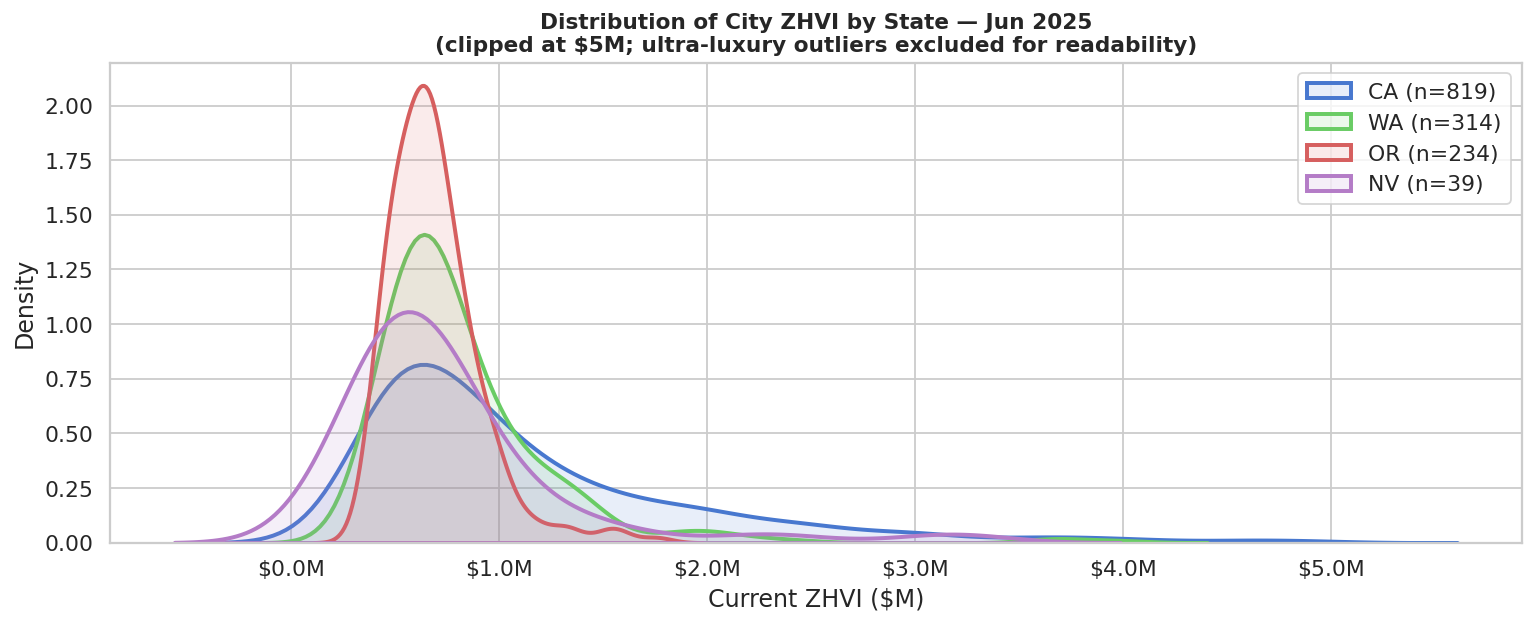

Current ZHVI percentiles by state (Jun 2025):
  CA:  p25: $560K  |  p50: $865K  |  p75: $1,480K  |  p90: $2,435K
  WA:  p25: $553K  |  p50: $705K  |  p75: $956K  |  p90: $1,312K
  OR:  p25: $543K  |  p50: $660K  |  p75: $790K  |  p90: $942K
  NV:  p25: $471K  |  p50: $569K  |  p75: $845K  |  p90: $1,380K


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
for state in ['CA', 'WA', 'OR', 'NV']:
    subset = cs[cs['State'] == state]['zhvi_current'].dropna()
    subset_clipped = subset[subset < 5e6]  # clip ultra-luxury outliers for density readability
    sns.kdeplot(subset_clipped / 1e6, ax=ax, label=f'{state} (n={len(subset)})',
                color=COLORS[state], linewidth=2.2, fill=True, alpha=0.12)

ax.set_xlabel('Current ZHVI ($M)')
ax.set_ylabel('Density')
ax.set_title('Distribution of City ZHVI by State — Jun 2025\n(clipped at $5M; ultra-luxury outliers excluded for readability)',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.legend()
plt.tight_layout()
plt.savefig('zhvi_distribution_by_state.png', bbox_inches='tight')
plt.show()

print('Current ZHVI percentiles by state (Jun 2025):')
pcts = [25, 50, 75, 90]
for state in ['CA', 'WA', 'OR', 'NV']:
    vals = cs[cs['State']==state]['zhvi_current'].quantile([p/100 for p in pcts])
    row = '  ' + state + ':  ' + '  |  '.join([f'p{p}: ${v/1e3:,.0f}K' for p, v in zip(pcts, vals)])
    print(row)

**Observations:**
- California's distribution is the widest and most right-skewed, reflecting massive geographic heterogeneity, from Inland Empire desert cities near 250K to Bay Area and LA coastal enclaves above 5M.
- Washington and Oregon have tighter, more bell-shaped distributions, concentrated in the $500K – $900K range.
- Nevada has the most affordable median but significant variance driven by the Las Vegas vs. rural markets split.

## 6) Metro-Level Appreciation Rankings

State-level medians mask significant within-state variation. Metro-level aggregation reveals which *markets*, not just which *states*, compounded the most over 10 years.

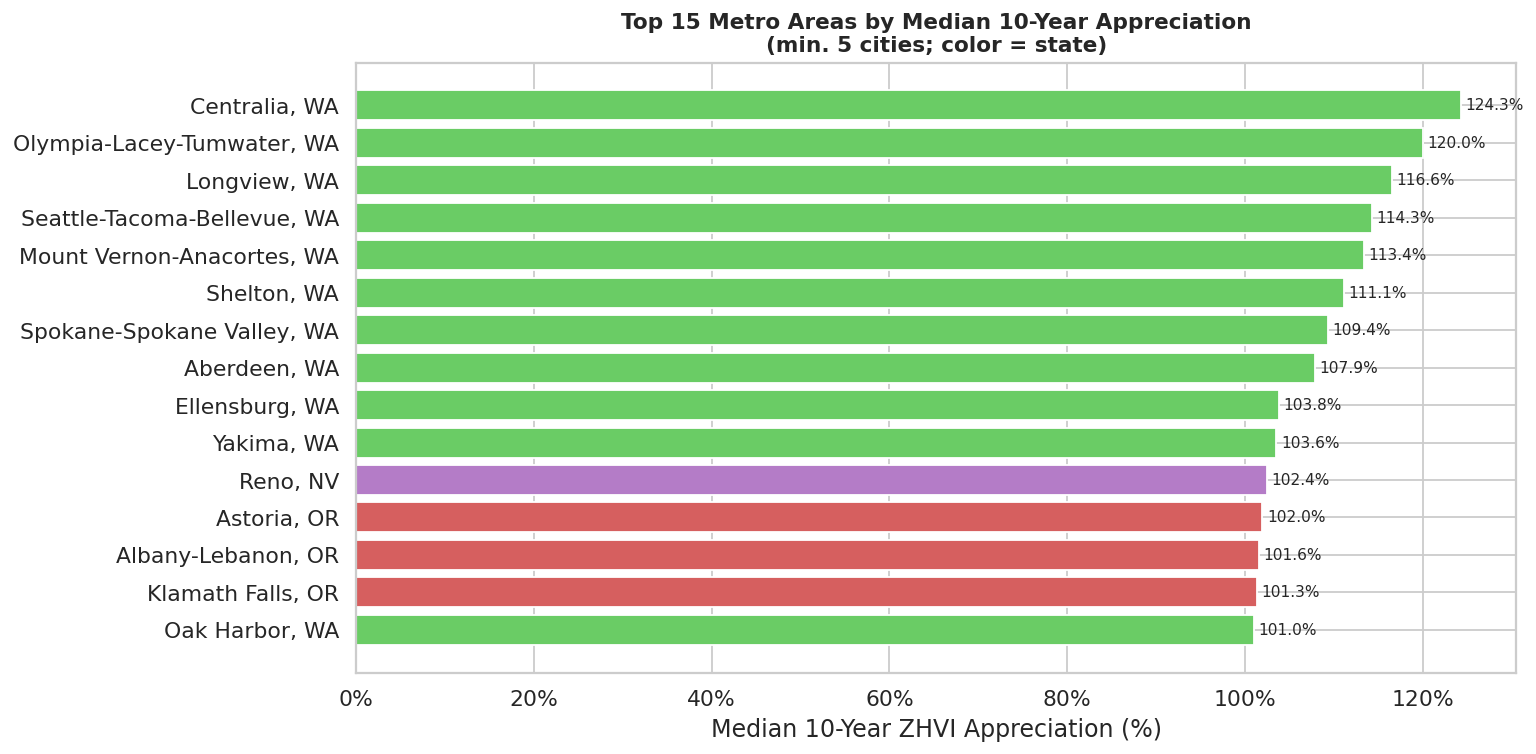

Top 5 appreciating metros (median across cities, min. 5 cities):
                      Metro  Median 10yr Appreciation (%)  Cities
              Centralia, WA                          $124      13
 Olympia-Lacey-Tumwater, WA                          $120       8
               Longview, WA                          $117      10
Seattle-Tacoma-Bellevue, WA                          $114      95
 Mount Vernon-Anacortes, WA                          $113       8


In [14]:
metro_app = (
    cs.groupby('Metro')['pct_change_10yr']
    .agg(['median', 'count'])
    .query('count >= 5')  # minimum 5 cities per metro for statistical credibility
    .sort_values('median', ascending=False)
    .head(15)
    .reset_index()
)

# Assign state color based on metro suffix

def metro_color(metro):
    for state, color in COLORS.items():
        if f', {state}' in metro:
            return color
    return '#888888'

colors_metro = [metro_color(m) for m in metro_app['Metro']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(metro_app['Metro'][::-1], metro_app['median'][::-1],
               color=colors_metro[::-1], edgecolor='white')
ax.set_xlabel('Median 10-Year ZHVI Appreciation (%)')
ax.set_title('Top 15 Metro Areas by Median 10-Year Appreciation\n(min. 5 cities; color = state)',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('top_metros_appreciation.png', bbox_inches='tight')
plt.show()

print('Top 5 appreciating metros (median across cities, min. 5 cities):')
print(metro_app.head(5)[['Metro', 'median', 'count']]
      .rename(columns={'median': 'Median 10yr Appreciation (%)', 'count': 'Cities'})
      .to_string(index=False))

**Observations:**
- The top appreciating metros are dominated by Washington state secondary markets, Centralia, Olympia-Lacey-Tumwater, and Longview, which benefited from Seattle-area price spillover and remote work demand.
- These are not luxury markets; they started from low 2015 baselines (~$200–350K) and were carried by strong demand inflows from Seattle workers priced out of the core metro.
- This is a textbook example of the **gateway city spillover effect**: when core metros become unaffordable, appreciation flows to adjacent commuter and exurban markets.

## 7) COVID-Era Shock Analysis (2019–2023)

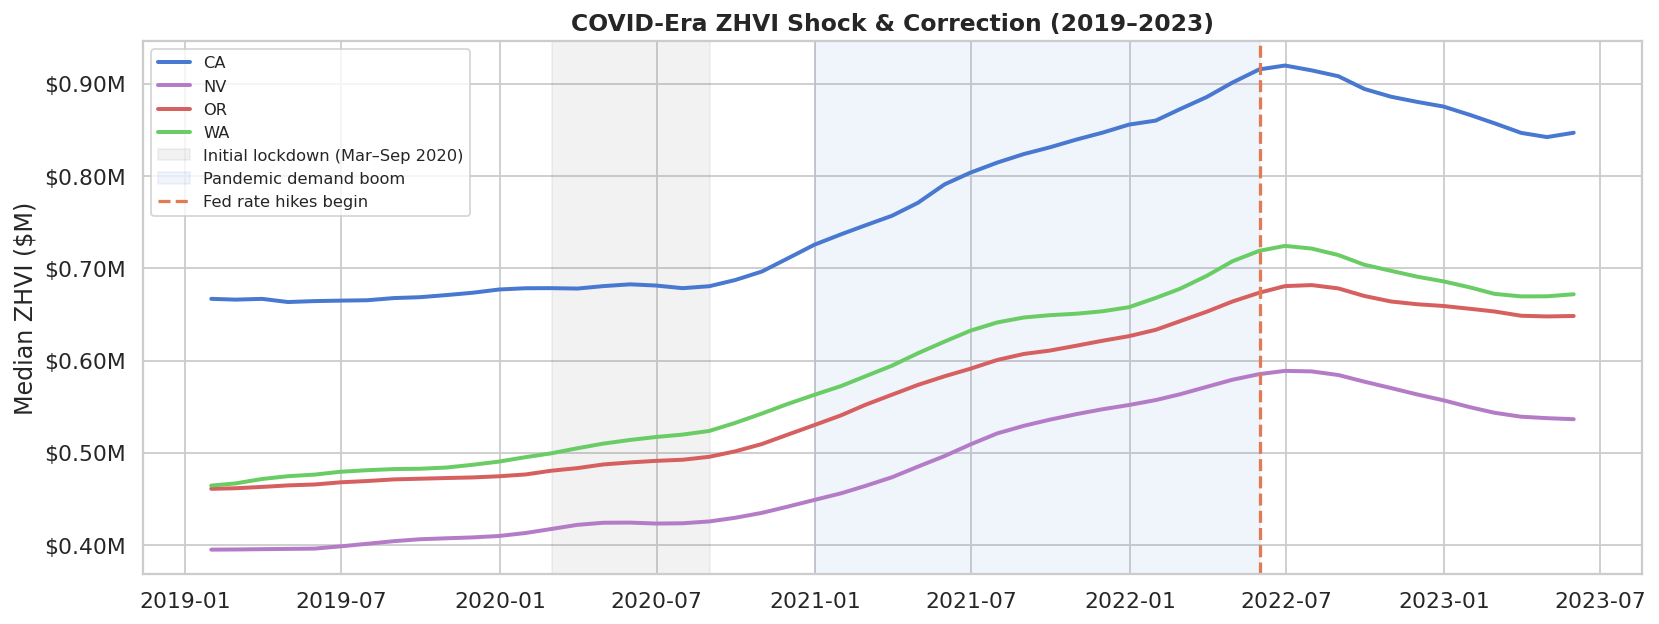

ZHVI at key COVID-era dates (state medians):
State                          CA     NV     OR     WA
Pre-COVID (Jan 2020)        $678K  $413K  $477K  $495K
Lockdown trough (Jun 2020)  $681K  $424K  $491K  $517K
Pandemic peak (~Jun 2022)   $920K  $589K  $681K  $724K
Post-correction (Jun 2023)  $850K  $537K  $649K  $676K


In [16]:
covid_window = df[(df['date'] >= '2019-01-01') & (df['date'] <= '2023-06-01')]
covid_state = covid_window.groupby(['State', 'date'])['zhvi'].median().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
for state, grp in covid_state.groupby('State'):
    ax.plot(grp['date'], grp['zhvi'] / 1e6, label=state,
            color=COLORS[state], linewidth=2.2)

ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-09-01'),
           alpha=0.10, color='gray', label='Initial lockdown (Mar–Sep 2020)')
ax.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2022-06-01'),
           alpha=0.08, color='#4878CF', label='Pandemic demand boom')
ax.axvline(pd.Timestamp('2022-06-01'), color='#e07b54',
           linestyle='--', linewidth=1.8, label='Fed rate hikes begin')

ax.set_title('COVID-Era ZHVI Shock & Correction (2019–2023)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Median ZHVI ($M)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.2f}M'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('covid_shock_analysis.png', bbox_inches='tight')
plt.show()

# Quantify the COVID boom

print('ZHVI at key COVID-era dates (state medians):')
milestones = {
    'Pre-COVID (Jan 2020)': '2020-01-31',
    'Lockdown trough (Jun 2020)': '2020-06-30',
    'Pandemic peak (~Jun 2022)': '2022-06-30',
    'Post-correction (Jun 2023)': '2023-06-30',
}
rows = []
for label, date_str in milestones.items():
    snap = df[df['date'] == pd.Timestamp(date_str)].groupby('State')['zhvi'].median()
    snap.name = label
    rows.append(snap)
milestone_df = pd.DataFrame(rows)
print(milestone_df.applymap(lambda x: f'${x/1e3:,.0f}K').to_string())

**Observations:**
- The initial lockdown (Mar–Sep 2020) produced only a brief deceleration, not a price decline, inventory froze alongside demand.
- The pandemic demand boom (Jan 2021–Jun 2022) drove the most compressed appreciation cycle in the dataset. What normally takes 5–7 years happened in 18 months.
- The Fed's rate hike cycle starting June 2022 created a rapid but incomplete correction. By June 2023, prices remained well above pre-COVID levels in all four states, the correction was a cooling, not a crash.

## 8) Appreciation vs. Volatility

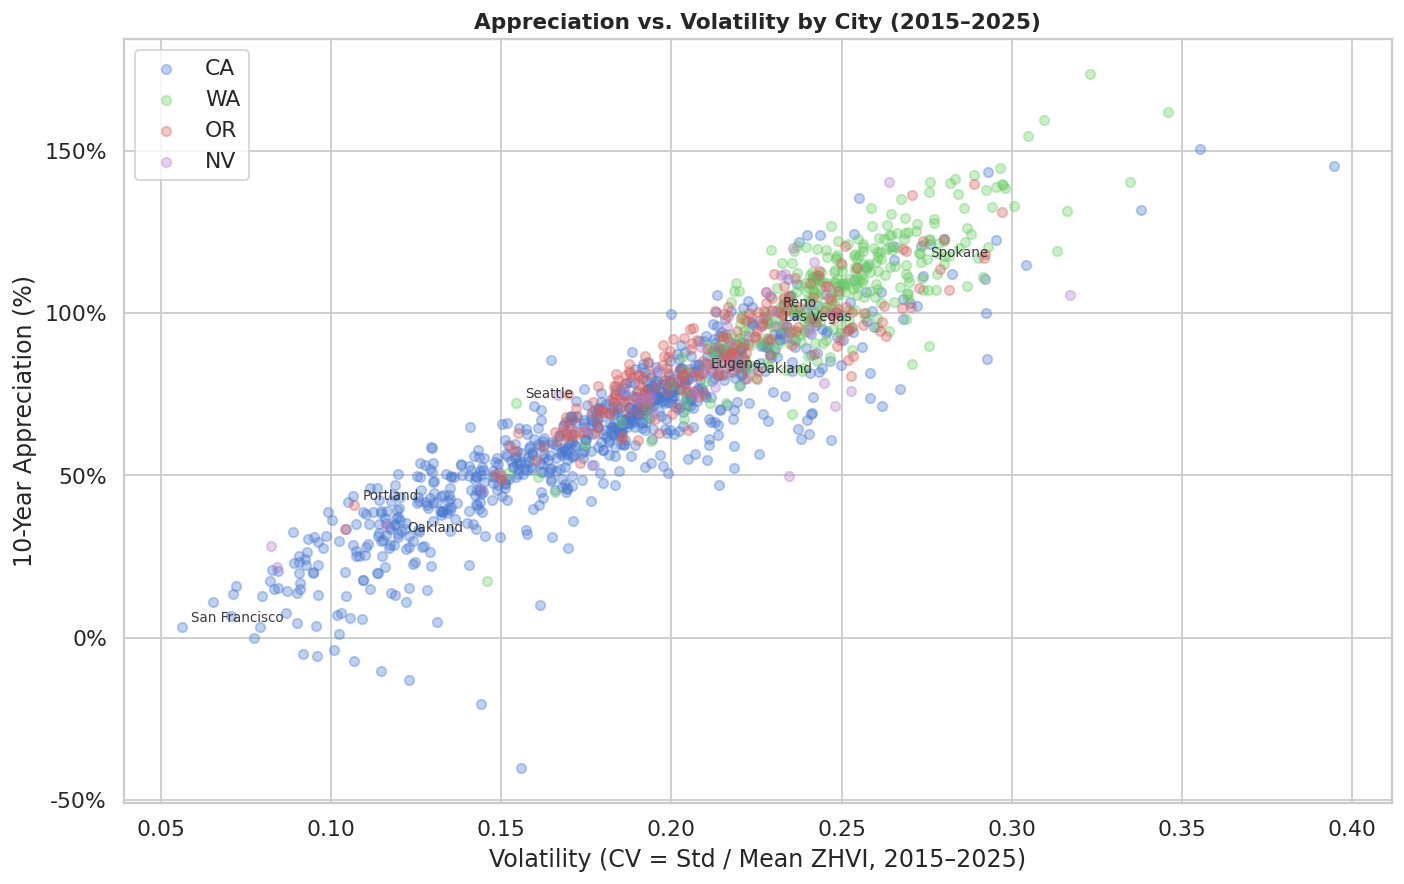

Pearson correlation (Appreciation vs. Volatility): 0.926

Extreme cities (high appreciation, moderate volatility):
RegionName State  pct_change_10yr  volatility_cv
     Vader    WA             $174             $0
  Packwood    WA             $162             $0
    Bucoda    WA             $159             $0
   Winlock    WA             $154             $0
   Landers    CA             $151             $0

Cities with negative appreciation:
   RegionName State  pct_change_10yr  zhvi_2015  zhvi_current
  Garberville    CA             $-40   $892,603      $534,213
      Hinkley    CA             $-21   $323,478      $256,944
    Pescadero    CA             $-13 $2,363,928    $2,056,435
Potter Valley    CA             $-10   $767,956      $688,960
  Laytonville    CA              $-7   $506,983      $471,002


In [18]:
fig, ax = plt.subplots(figsize=(11, 7))
for state in ['CA', 'WA', 'OR', 'NV']:
    s = cs[cs['State'] == state]
    ax.scatter(s['volatility_cv'], s['pct_change_10yr'],
               alpha=0.35, s=28, label=state, color=COLORS[state])

# Annotate notable named cities

notable = ['Seattle', 'San Francisco', 'Portland', 'Las Vegas',
           'Oakland', 'Spokane', 'Eugene', 'Reno']
for _, row in cs[cs['RegionName'].isin(notable)].iterrows():
    ax.annotate(row['RegionName'],
                xy=(row['volatility_cv'], row['pct_change_10yr']),
                xytext=(5, 3), textcoords='offset points',
                fontsize=7.5, alpha=0.9)

ax.set_xlabel('Volatility (CV = Std / Mean ZHVI, 2015–2025)')
ax.set_ylabel('10-Year Appreciation (%)')
ax.set_title('Appreciation vs. Volatility by City (2015–2025)',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend()
plt.tight_layout()
plt.savefig('appreciation_vs_volatility.png', bbox_inches='tight')
plt.show()

# Correlation

corr = cs[['pct_change_10yr', 'volatility_cv']].corr().iloc[0, 1]
print(f'Pearson correlation (Appreciation vs. Volatility): {corr:.3f}')
print()
print('Extreme cities (high appreciation, moderate volatility):')
top_cities = cs.nlargest(5, 'pct_change_10yr')[['RegionName','State','pct_change_10yr','volatility_cv']]
print(top_cities.to_string(index=False))
print()
print('Cities with negative appreciation:')
neg = cs[cs['pct_change_10yr'] < 0][['RegionName','State','pct_change_10yr','zhvi_2015','zhvi_current']]
print(neg.sort_values('pct_change_10yr').head(5).to_string(index=False))

**Observations:**
- There is a **positive correlation between volatility and appreciation**, cities that experienced larger swings also tended to compound more over the decade. This is consistent with risk-return theory applied to real estate markets.
- The strongest appreciators (Vader, Packwood, Bucoda, WA) are low-base rural markets that rode the pandemic spillover wave, high CV reflects their boom-bust sensitivity to migration trends.
- Cities with **negative 10-year appreciation**, Garberville and Hinkley, CA among others, reflect idiosyncratic local factors: industry decline, population loss, or environmental events rather than macro market dynamics.

## 9) Seasonal Patterns

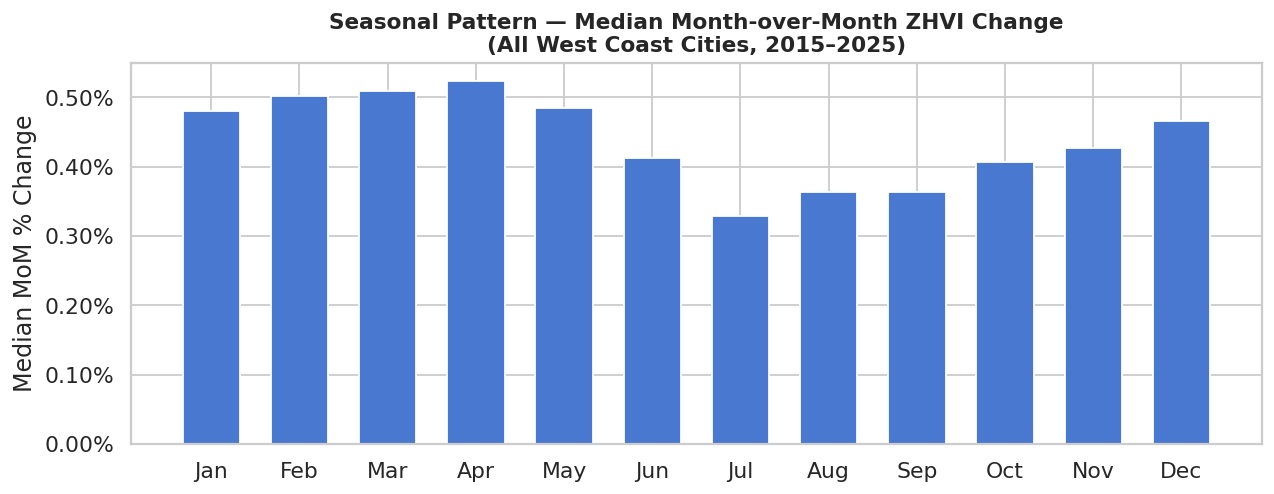

Monthly median MoM change:
  Jan: +0.480%
  Feb: +0.502%
  Mar: +0.509%
  Apr: +0.524% ◀ peak
  May: +0.484%
  Jun: +0.413%
  Jul: +0.329% ◀ trough
  Aug: +0.363%
  Sep: +0.363%
  Oct: +0.407%
  Nov: +0.427%
  Dec: +0.465%


In [20]:
seasonal = df.groupby('month')['mom_pct_change'].median().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['#4878CF' if v >= 0 else '#d9534f'
              for v in seasonal['mom_pct_change']]
ax.bar(seasonal['month'], seasonal['mom_pct_change'],
       color=bar_colors, edgecolor='white', width=0.65)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Median MoM % Change')
ax.set_title('Seasonal Pattern — Median Month-over-Month ZHVI Change\n(All West Coast Cities, 2015–2025)',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}%'))
plt.tight_layout()
plt.savefig('seasonal_mom_pattern.png', bbox_inches='tight')
plt.show()

print('Monthly median MoM change:')
for i, row in seasonal.iterrows():
    marker = ' ◀ peak' if row['mom_pct_change'] == seasonal['mom_pct_change'].max() else ''
    marker = marker or (' ◀ trough' if row['mom_pct_change'] == seasonal['mom_pct_change'].min() else '')
    print(f'  {month_labels[int(row["month"])-1]:>3}: {row["mom_pct_change"]:+.3f}%{marker}')

**Observations:**
- West Coast housing exhibits a clear seasonal rhythm: **spring acceleration (Jan–Apr), summer plateau, fall/winter deceleration**.
- April is the strongest month (+0.524%), followed by a summer softening (July at +0.329% is the weakest growth month despite high transaction volume).
- Crucially, **no month shows negative median MoM growth**, West Coast housing has been persistently positive across all calendar months over this decade, even controlling for seasonal effects.
- This seasonal pattern will be encoded as a feature in Part 3's predictive model.

## 10) Feature Correlation: Part 3 Preview

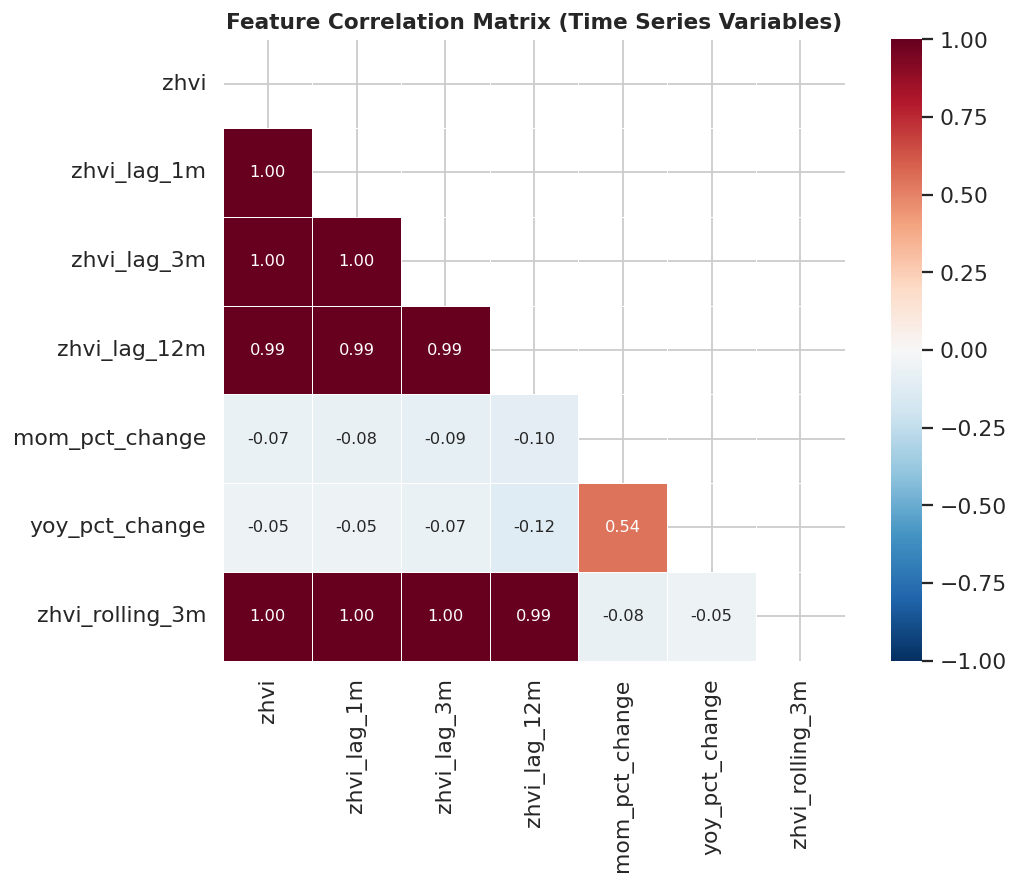

Correlation with zhvi (target):
  zhvi_rolling_3m       : +0.9999
  zhvi_lag_1m           : +0.9999
  zhvi_lag_3m           : +0.9991
  zhvi_lag_12m          : +0.9925
  yoy_pct_change        : -0.0477
  mom_pct_change        : -0.0670

Implication for Part 3:
  Lag features (1m, 3m, 12m) and rolling mean are strongly correlated with ZHVI
  they will serve as primary predictors. MoM and YoY change rates have near-zero
  correlation with absolute ZHVI level, but will be valuable for predicting change.


In [23]:
feature_cols = ['zhvi', 'zhvi_lag_1m', 'zhvi_lag_3m', 'zhvi_lag_12m',
                'mom_pct_change', 'yoy_pct_change', 'zhvi_rolling_3m']

corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            mask=mask, ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix (Time Series Variables)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation_matrix.png', bbox_inches='tight')
plt.show()

print('Correlation with zhvi (target):')
target_corr = corr_matrix['zhvi'].drop('zhvi').sort_values(ascending=False)
for feat, val in target_corr.items():
    print(f'  {feat:<22}: {val:+.4f}')
print()
print('Implication for Part 3:')
print('  Lag features (1m, 3m, 12m) and rolling mean are strongly correlated with ZHVI')
print('  they will serve as primary predictors. MoM and YoY change rates have near-zero')
print('  correlation with absolute ZHVI level, but will be valuable for predicting change.')

## 11) Key Findings Summary

In [26]:

print('Key Findings: From Part 2 - EDA\n')

print()
print('1. STATE TIERS\n')
print('   CA > WA > OR > NV in median ZHVI throughout the decade.')
print('   The gap widened: CA grew from ~$460K to $865K median.')
print()
print('2. COVID BOOM: UNPRECEDENTED COMPRESSION\n')
print('   All states hit YoY growth peaks of 20–26% in 2021.')
print('   WA peaked latest and highest (Jul 2021, +26.2% YoY).')
print('   NV had the deepest correction (-8.2% YoY trough, May 2023).')
print()
print('3. METRO SPILLOVER STORY\n')
print('   Top-appreciating metros are WA secondary markets')
print('   (Centralia +124%, Olympia +120%, Longview +117%).')
print('   Classic gateway-city pricing pressure spillover.')
print()
print('4. RISK-RETURN IN HOUSING\n')
print('   Volatility and 10-yr appreciation are positively correlated.')
print('   Higher-volatility markets rewarded long-term holders.')
print()
print('5. SEASONALITY IS CONSISTENT\n')
print('   Spring (Jan–Apr) strongest; July weakest MoM.')
print('   No month shows median negative MoM over the full 10 years.')
print()
print('6. FEATURE ENGINEERING SIGNAL\n')
print('   zhvi_lag_1m (r=0.9999), zhvi_lag_12m (r=0.9925) are')
print('   dominant predictors of current ZHVI level for Part 3.')
print()
print('Part 3: Build the housing price predictor using these features.')

Key Findings: From Part 2 - EDA


1. STATE TIERS

   CA > WA > OR > NV in median ZHVI throughout the decade.
   The gap widened: CA grew from ~$460K to $865K median.

2. COVID BOOM: UNPRECEDENTED COMPRESSION

   All states hit YoY growth peaks of 20–26% in 2021.
   WA peaked latest and highest (Jul 2021, +26.2% YoY).
   NV had the deepest correction (-8.2% YoY trough, May 2023).

3. METRO SPILLOVER STORY

   Top-appreciating metros are WA secondary markets
   (Centralia +124%, Olympia +120%, Longview +117%).
   Classic gateway-city pricing pressure spillover.

4. RISK-RETURN IN HOUSING

   Volatility and 10-yr appreciation are positively correlated.
   Higher-volatility markets rewarded long-term holders.

5. SEASONALITY IS CONSISTENT

   Spring (Jan–Apr) strongest; July weakest MoM.
   No month shows median negative MoM over the full 10 years.

6. FEATURE ENGINEERING SIGNAL

   zhvi_lag_1m (r=0.9999), zhvi_lag_12m (r=0.9925) are
   dominant predictors of current ZHVI level for Part 3.